In [2]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset('../data/era5/bsw_ontario/daily_min/era5_min_1996_11.nc', engine='netcdf4')

# See everything — dimensions, variables, coords, attributes
ds

<xarray.Dataset> Size: 130kB
Dimensions:     (valid_time: 30, latitude: 27, longitude: 40)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 240B 1996-11-01 ... 1996-11-30
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
    number      int64 8B ...
Data variables:
    mn2t        (valid_time, latitude, longitude) float32 130kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-01T02:22 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
import xarray as xr
import glob

# Check one from each folder
ds_max = xr.open_dataset('../data/era5/bsw_ontario/daily_max/era5_max_1980_01.nc', engine='h5netcdf')
ds_min = xr.open_dataset('../data/era5/bsw_ontario/daily_min/era5_min_1980_01.nc', engine='h5netcdf')

print('tmax vars:', list(ds_max.data_vars))
print('tmin vars:', list(ds_min.data_vars))

tmax vars: ['mx2t']
tmin vars: ['mn2t']


In [5]:
import xarray as xr
import glob
import os

max_dir = '../data/era5/bsw_ontario/daily_max'
min_dir = '../data/era5/bsw_ontario/daily_min'

datasets = []

for max_path in sorted(glob.glob(f'{max_dir}/era5_max_*.nc')):
    # Build matching tmin filename
    fname    = os.path.basename(max_path).replace('era5_max_', 'era5_min_')
    min_path = os.path.join(min_dir, fname)

    if not os.path.exists(min_path):
        print(f'  missing tmin: {fname}')
        continue

    ds_max = xr.open_dataset(max_path, engine='h5netcdf')
    ds_min = xr.open_dataset(min_path, engine='h5netcdf')
    ds     = xr.merge([ds_max, ds_min])
    datasets.append(ds)
    ds_max.close()
    ds_min.close()

# Concatenate all months into one dataset
ds_all = xr.concat(datasets, dim='valid_time').sortby('valid_time')
print(ds_all)
print(ds_all.dims)
print(ds_all['mx2t'].shape)
print(ds_all['mn2t'].shape)

<positron-console-cell-5>:21: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
<positron-console-cell-5>:21: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
<positron-console-cell-5>:21: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead 

<xarray.Dataset> Size: 98MB
Dimensions:     (valid_time: 11323, latitude: 27, longitude: 40)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 91kB 1980-01-01 ... 2010-12-31
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
    number      int64 8B 0
Data variables:
    mx2t        (valid_time, latitude, longitude) float32 49MB 257.7 ... 275.1
    mn2t        (valid_time, latitude, longitude) float32 49MB 257.4 ... 274.8
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-27T22:16 GRIB to CDM+CF via cfgrib-0.9.1...
FrozenMappingWarningOnValuesAccess({'valid_time': 11323, 'latitude': 27, 'longitude': 40})
(11323, 27, 40)
(1

In [7]:
# Single month
ds_all.sel(valid_time='1990-07')

# All Julys
test =  ds_all.sel(valid_time=ds_all.valid_time.dt.month == 7)

In [11]:
import pandas as pd

# Select one month
ds_month = ds_all.sel(valid_time='1990-07')

# Convert to dataframe and print all values
df = ds_month.to_dataframe().reset_index()
pd.set_option('display.max_rows', None)
print(df)

      valid_time  latitude  longitude        mx2t        mn2t  number
0     1990-07-01     54.75     -95.00  291.892151  291.114105       0
1     1990-07-01     54.75     -94.75  291.648346  290.971191       0
2     1990-07-01     54.75     -94.50  291.341949  290.720459       0
3     1990-07-01     54.75     -94.25  290.464081  289.984283       0
4     1990-07-01     54.75     -94.00  291.019012  290.394531       0
5     1990-07-01     54.75     -93.75  291.551086  290.806305       0
6     1990-07-01     54.75     -93.50  291.595123  290.813477       0
7     1990-07-01     54.75     -93.25  291.578674  290.742920       0
8     1990-07-01     54.75     -93.00  291.426483  290.459473       0
9     1990-07-01     54.75     -92.75  291.214020  290.261627       0
10    1990-07-01     54.75     -92.50  291.150543  290.215576       0
11    1990-07-01     54.75     -92.25  291.079803  290.172211       0
12    1990-07-01     54.75     -92.00  291.046204  290.164703       0
13    1990-07-01    

In [9]:
ds_month = ds_all.sel(valid_time='1990-07')

print('=== mx2t ===')
print(f'  min: {float(ds_month["mx2t"].min()) - 273.15:.2f} °C')
print(f'  max: {float(ds_month["mx2t"].max()) - 273.15:.2f} °C')
print(f'  mean: {float(ds_month["mx2t"].mean()) - 273.15:.2f} °C')

print('=== mn2t ===')
print(f'  min: {float(ds_month["mn2t"].min()) - 273.15:.2f} °C')
print(f'  max: {float(ds_month["mn2t"].max()) - 273.15:.2f} °C')
print(f'  mean: {float(ds_month["mn2t"].mean()) - 273.15:.2f} °C')

=== mx2t ===
  min: 5.88 °C
  max: 25.46 °C
  mean: 17.47 °C
=== mn2t ===
  min: 5.39 °C
  max: 24.77 °C
  mean: 16.90 °C


In [10]:

ds_month = ds_all.sel(valid_time='1990-07')

print('=== Geographic bounds ===')
print(f'  lat min: {float(ds_month.latitude.min()):.4f}')
print(f'  lat max: {float(ds_month.latitude.max()):.4f}')
print(f'  lon min: {float(ds_month.longitude.min()):.4f}')
print(f'  lon max: {float(ds_month.longitude.max()):.4f}')

=== Geographic bounds ===
  lat min: 48.2500
  lat max: 54.7500
  lon min: -95.0000
  lon max: -85.2500


In [18]:
ds_monthly = xr.Dataset({
    'mx2t': ds_all['mx2t'].resample(valid_time='1ME').mean() - 273.15,
    'mn2t': ds_all['mn2t'].resample(valid_time='1ME').mean() - 273.15,
})

# Update units attribute
ds_monthly['mx2t'].attrs['units'] = 'degC'
ds_monthly['mn2t'].attrs['units'] = 'degC'

print(ds_monthly)

# Sanity check — July 1990 should be positive values for BSW Ontario
print('\n=== July 1990 ===')
print(f'  mx2t mean: {float(ds_monthly["mx2t"].sel(valid_time="1990-07").mean()):.2f} °C')
print(f'  mn2t mean: {float(ds_monthly["mn2t"].sel(valid_time="1990-07").mean()):.2f} °C')

<xarray.Dataset> Size: 3MB
Dimensions:     (latitude: 27, longitude: 40, valid_time: 372)
Coordinates:
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
  * valid_time  (valid_time) datetime64[ns] 3kB 1980-01-31 ... 2010-12-31
    number      int64 8B 0
Data variables:
    mx2t        (valid_time, latitude, longitude) float32 2MB -22.09 ... -9.879
    mn2t        (valid_time, latitude, longitude) float32 2MB -22.34 ... -10.27

=== July 1990 ===
  mx2t mean: 17.47 °C
  mn2t mean: 16.90 °C


In [16]:

ds_ua = xr.open_dataset('../data/era5/bsw_ontario/era5_all_years_01_avgua.nc', engine='h5netcdf')
ds_ad = xr.open_dataset('../data/era5/bsw_ontario/era5_all_years_01_avgad.nc', engine='h5netcdf')

print('=== avgua ===')
print(list(ds_ua.data_vars))

print('=== avgad ===')
print(list(ds_ad.data_vars))

=== avgua ===
['t2m', 'd2m']
=== avgad ===
['tp']


In [19]:

data_dir = '../data/era5/bsw_ontario'

ds_avgua = xr.open_mfdataset(
    sorted(glob.glob(f'{data_dir}/era5_all_years_*_avgua.nc')),
    combine='nested',
    concat_dim='valid_time',
    engine='h5netcdf'
).sortby('valid_time')

ds_avgad = xr.open_mfdataset(
    sorted(glob.glob(f'{data_dir}/era5_all_years_*_avgad.nc')),
    combine='nested',
    concat_dim='valid_time',
    engine='h5netcdf'
).sortby('valid_time')

ds_monthly2 = xr.merge([ds_avgua, ds_avgad])

ds_monthly2['t2m'] = ds_monthly2['t2m'] - 273.15
ds_monthly2['d2m'] = ds_monthly2['d2m'] - 273.15
ds_monthly2['tp']  = ds_monthly2['tp'] * 1000

ds_monthly2['t2m'].attrs['units'] = 'degC'
ds_monthly2['d2m'].attrs['units'] = 'degC'
ds_monthly2['tp'].attrs['units']  = 'mm'

print(ds_monthly2)

<xarray.Dataset> Size: 10MB
Dimensions:     (valid_time: 744, latitude: 27, longitude: 40)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 1980-01-01 ... 2010-12-01T06:...
    expver      (valid_time) object 6kB dask.array<chunksize=(31,), meta=np.ndarray>
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1

<positron-console-cell-19>:17: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
<positron-console-cell-19>:17: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
<positron-console-cell-19>:17: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to le

In [22]:
print('ds_monthly times:', ds_monthly.valid_time.values[:3])
print('ds_monthly2 times:', ds_monthly2.valid_time.values[:3])

ds_monthly times: ['1980-01-31T00:00:00.000000000' '1980-02-29T00:00:00.000000000'
 '1980-03-31T00:00:00.000000000']
ds_monthly2 times: ['1980-01-01T00:00:00.000000000' '1980-01-01T06:00:00.000000000'
 '1980-02-01T00:00:00.000000000']


In [27]:
import pandas as pd

# Fix ds_monthly2 — drop duplicate timestamps and snap to month start
ds_monthly2 = ds_monthly2.sel(
    valid_time=ds_monthly2.valid_time.dt.hour == 0  # keep only 00:00 timestamps
)

# Snap ds_monthly to month start to match ds_monthly2
ds_monthly['valid_time'] = ds_monthly2.valid_time.values

# Now merge
ds_combined = xr.merge([ds_monthly, ds_monthly2])
print(ds_combined)
print(f'Time steps: {len(ds_combined.valid_time)}')  # should be 372

# Check timestamps look right
print(ds_combined.valid_time.values[:5])

<xarray.Dataset> Size: 8MB
Dimensions:     (latitude: 27, longitude: 40, valid_time: 372)
Coordinates:
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
  * valid_time  (valid_time) datetime64[ns] 3kB 1980-01-01 ... 2010-12-01
    expver      (valid_time) object 3kB dask.array<chunksize=(31,), meta=np.ndarray>
    number      int64 8B 0
Data variables:
    mx2t        (valid_time, latitude, longitude) float32 2MB -22.09 ... -9.879
    mn2t        (valid_time, latitude, longitude) float32 2MB -22.34 ... -10.27
    t2m         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
Time steps: 372
['1980-01-01T00:00:00.

<positron-console-cell-27>:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.


add geopotential

In [28]:
ds_geo = xr.open_dataset('../data/era5/bsw_ontario/era5_geopotential.nc', engine='h5netcdf')

# Convert to altitude and squeeze time dim — it's static
A = (ds_geo['z'] / 9.80665).squeeze()
print(f'Altitude range: {float(A.min()):.0f} – {float(A.max()):.0f} m')

ds_combined['A'] = A
print(ds_combined)

Altitude range: 83 – 506 m
<xarray.Dataset> Size: 8MB
Dimensions:     (latitude: 27, longitude: 40, valid_time: 372)
Coordinates:
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
  * valid_time  (valid_time) datetime64[ns] 3kB 1980-01-01 ... 2010-12-01
    expver      (valid_time) object 3kB dask.array<chunksize=(31,), meta=np.ndarray>
    number      int64 8B 0
Data variables:
    mx2t        (valid_time, latitude, longitude) float32 2MB -22.09 ... -9.879
    mn2t        (valid_time, latitude, longitude) float32 2MB -22.34 ... -10.27
    t2m         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    A      

In [29]:
def calc_esat(T):
    """Saturation vapour pressure (kPa) — August-Roche-Magnus"""
    return 0.61094 * np.exp((17.625 * T) / (T + 243.04))

T_mean = ds_combined['t2m']   # °C
T_max  = ds_combined['mx2t']  # °C
T_min  = ds_combined['mn2t']  # °C
A      = ds_combined['A']     # altitude (m) — shape (lat, lon)

# Vapour pressures
es_max = calc_esat(T_max)
es_min = calc_esat(T_min)
es_dew = calc_esat(T_min - 2.5)  # Hogg 1997 approximation

# D as per Hogg 1997 Eq. 3
D = 0.5 * (es_max - es_min) - es_dew
D = D.clip(min=0)

# PET as per Hogg 1997 Eqs. 4a-4c
PET = xr.where(
    T_mean > 10,
    93 * D * np.exp(A / 9300),
    xr.where(
        T_mean > -5,
        (6.2 * T_mean + 31) * D * np.exp(A / 9300),
        0.0
    )
)
PET.name = 'PET'
PET.attrs['units'] = 'mm/month'

ds_combined['es_max'] = es_max
ds_combined['es_min'] = es_min
ds_combined['es_dew'] = es_dew
ds_combined['D']      = D
ds_combined['PET']    = PET

# Sanity check
print('\n=== July 1990 ===')
print(f'  A mean:    {float(A.mean()):.0f} m')
print(f'  es_max:    {float(es_max.sel(valid_time="1990-07").mean()):.4f} kPa')
print(f'  es_min:    {float(es_min.sel(valid_time="1990-07").mean()):.4f} kPa')
print(f'  es_dew:    {float(es_dew.sel(valid_time="1990-07").mean()):.4f} kPa')
print(f'  D mean:    {float(D.sel(valid_time="1990-07").mean()):.4f} kPa')
print(f'  PET mean:  {float(PET.sel(valid_time="1990-07").mean()):.2f} mm/month')
print(f'  PET min:   {float(PET.sel(valid_time="1990-07").min()):.2f} mm/month')
print(f'  PET max:   {float(PET.sel(valid_time="1990-07").max()):.2f} mm/month')


=== July 1990 ===
  A mean:    298 m
  es_max:    1.9948 kPa
  es_min:    1.9237 kPa
  es_dew:    1.6393 kPa
  D mean:    0.0000 kPa
  PET mean:  0.00 mm/month
  PET min:   0.00 mm/month
  PET max:   0.00 mm/month


In [31]:
# Use isel for time too to avoid ambiguity
july_1990_idx = list(ds_combined.valid_time.values).index(
    ds_combined.sel(valid_time='1990-07-01').valid_time.values
)

print('Single grid cell — July 1990:')
print(f'  mx2t: {float(ds_combined["mx2t"].isel(valid_time=july_1990_idx, latitude=13, longitude=20)):.2f} °C')
print(f'  mn2t: {float(ds_combined["mn2t"].isel(valid_time=july_1990_idx, latitude=13, longitude=20)):.2f} °C')
print(f'  t2m:  {float(ds_combined["t2m"].isel(valid_time=july_1990_idx, latitude=13, longitude=20)):.2f} °C')

# Diurnal range across whole domain for that time step
diurnal_range = ds_combined['mx2t'] - ds_combined['mn2t']
print(f'\nDiurnal range July 1990:')
print(f'  mean: {float(diurnal_range.isel(valid_time=july_1990_idx).mean()):.2f} °C')
print(f'  min:  {float(diurnal_range.isel(valid_time=july_1990_idx).min()):.2f} °C')
print(f'  max:  {float(diurnal_range.isel(valid_time=july_1990_idx).max()):.2f} °C')

Single grid cell — July 1990:
  mx2t: 17.49 °C
  mn2t: 16.80 °C
  t2m:  17.40 °C

Diurnal range July 1990:
  mean: 0.57 °C
  min:  0.12 °C
  max:  0.78 °C


In [25]:
# Check each component for July 1990
t_max_july = ds_combined['mx2t'].sel(valid_time='1990-07')
t_min_july = ds_combined['mn2t'].sel(valid_time='1990-07')
t_dew_july = ds_combined['d2m'].sel(valid_time='1990-07')

print('T_max mean:', float(t_max_july.mean()), '°C')
print('T_min mean:', float(t_min_july.mean()), '°C')
print('T_dew mean:', float(t_dew_july.mean()), '°C')

es_max_july = calc_esat(t_max_july)
es_min_july = calc_esat(t_min_july)
es_dew_july = calc_esat(t_dew_july)

print('es_max mean:', float(es_max_july.mean()), 'kPa')
print('es_min mean:', float(es_min_july.mean()), 'kPa')
print('es_dew mean:', float(es_dew_july.mean()), 'kPa')

print('0.5*(es_max - es_min) mean:', float((0.5 * (es_max_july - es_min_july)).mean()))
print('D before clip mean:', float((0.5 * (es_max_july - es_min_july) - es_dew_july).mean()))

T_max mean: 17.469364166259766 °C
T_min mean: 16.895923614501953 °C
T_dew mean: 11.287343978881836 °C
es_max mean: 1.9948084354400635 kPa
es_min mean: 1.9237245321273804 kPa
es_dew mean: 1.337921380996704 kPa
0.5*(es_max - es_min) mean: 0.0355418436229229
D before clip mean: -1.3023794889450073


In [8]:
import xarray as xr
import glob
import os

data_dir = '../data/era5/bsw_ontario/daily_minmax'

for fpath in sorted(glob.glob(f'{data_dir}/era5_minmax_*.nc')):
    ds = xr.open_dataset(fpath, engine='h5netcdf')
    if 'mn2t' not in ds.data_vars:
        print(f'  MISSING mn2t: {os.path.basename(fpath)} — vars: {list(ds.data_vars)}')
    ds.close()

  MISSING mn2t: era5_minmax_1980_01.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_02.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_03.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_04.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_05.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_06.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_07.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_08.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_09.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_10.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_11.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1980_12.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1981_01.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1981_02.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1981_03.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1981_04.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1981_05.nc — vars: ['mx2t']
  MISSING mn2t: era5_minmax_1981_06.nc — vars: [

KeyError: "No variable named 'mx2t'. Variables on the dataset include ['t2m', 'number', 'valid_time', 'latitude', 'longitude', 'expver']"

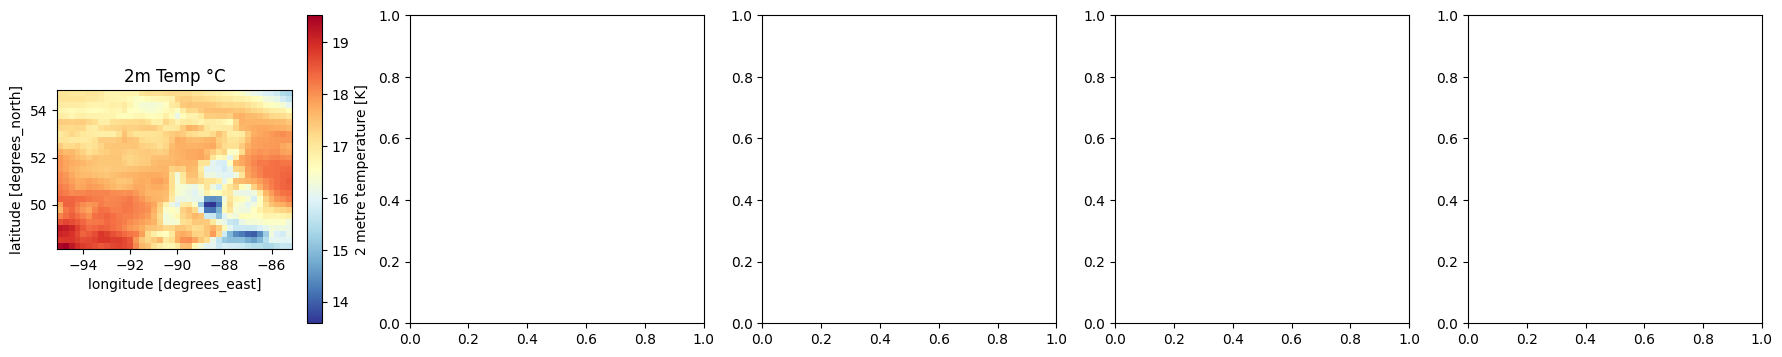

In [12]:
# Plot all variables in one call — xarray's built-in plot is great for this
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

vars_cfg = {
    't2m':  ('2m Temp °C',      lambda x: x - 273.15, 'RdYlBu_r'),
    'mx2t': ('Max Temp °C',     lambda x: x - 273.15, 'Reds'),
    'mn2t': ('Min Temp °C',     lambda x: x - 273.15, 'Blues'),
    'd2m':  ('Dewpoint °C',     lambda x: x - 273.15, 'BrBG'),
    'tp':   ('Precip mm',       lambda x: x * 1000,   'Blues'),
}

for ax, (var, (title, fn, cmap)) in zip(axes, vars_cfg.items()):
    data = fn(ds[var].squeeze())
    data.plot(ax=ax, cmap=cmap, add_colorbar=True)
    ax.set_title(title)
    ax.set_aspect('equal')

plt.suptitle('ERA5 BSW Ontario — July 1990', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# In a notebook cell, confirm the files are readable
import xarray as xr
import os

data_dir = '../data/era5/bsw_ontario'

for f in sorted(os.listdir(data_dir)):
    fpath = os.path.join(data_dir, f)
    size  = os.path.getsize(fpath) / 1e6
    try:
        ds = xr.open_dataset(fpath, engine='netcdf4')
        print(f'  OK  {f}  {size:.1f} MB  vars={list(ds.data_vars)}')
        ds.close()
    except Exception as e:
        print(f'  BAD {f}  {size:.1f} MB  → {e}')

  BAD .DS_Store  0.0 MB  → [Errno -51] NetCDF: Unknown file format: '/Users/jgoldman/Documents/projects/era5_weather_retrieve/data/era5/bsw_ontario/.DS_Store'
  BAD era5_1980_01.nc  0.1 MB  → [Errno -51] NetCDF: Unknown file format: '/Users/jgoldman/Documents/projects/era5_weather_retrieve/data/era5/bsw_ontario/era5_1980_01.nc'
  BAD era5_1980_02.nc  0.1 MB  → [Errno -51] NetCDF: Unknown file format: '/Users/jgoldman/Documents/projects/era5_weather_retrieve/data/era5/bsw_ontario/era5_1980_02.nc'
  BAD era5_1980_03.nc  0.1 MB  → [Errno -51] NetCDF: Unknown file format: '/Users/jgoldman/Documents/projects/era5_weather_retrieve/data/era5/bsw_ontario/era5_1980_03.nc'
  BAD era5_1980_04.nc  0.1 MB  → [Errno -51] NetCDF: Unknown file format: '/Users/jgoldman/Documents/projects/era5_weather_retrieve/data/era5/bsw_ontario/era5_1980_04.nc'
  BAD era5_1980_05.nc  0.1 MB  → [Errno -51] NetCDF: Unknown file format: '/Users/jgoldman/Documents/projects/era5_weather_retrieve/data/era5/bsw_ontario/era

In [19]:
import xarray as xr

ds = xr.open_dataset('../data/era5/bsw_ontario/era5_all_years_01.nc', engine='netcdf4')
print(ds)
print(ds.dims)
print(ds['t2m'].shape)  # should be (31, lat, lon) — one timestep per year

OSError: [Errno -51] NetCDF: Unknown file format: '/Users/jgoldman/Documents/projects/era5_weather_retrieve/data/era5/bsw_ontario/era5_all_years_01.nc'

In [2]:
import xarray as xr
import h5py

ds = xr.open_dataset('/Users/jgoldman/Documents/projects/era5_weather_retrieve/data/era5/bsw_ontario/era5_all_years_01_extracted/data_stream-moda_stepType-avgua.nc', engine='h5netcdf')
print(ds)
print(ds.dims)
print(ds['t2m'].shape)  # should be (31, lat, lon) — one timestep per year

<xarray.Dataset> Size: 269kB
Dimensions:     (valid_time: 31, latitude: 27, longitude: 40)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 248B 1980-01-01 ... 2010-01-01
    expver      (valid_time) <U4 496B ...
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 134kB ...
    d2m         (valid_time, latitude, longitude) float32 134kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-27T20:03 GRIB to CDM+CF via cfgrib-0.9.1...
FrozenMappingWarningOnValuesAccess({'valid_time': 31, 'latitude': 27, 'longitude': 40})
(

In [2]:
import xarray as xr
import glob
import dask



data_dir = '../data/era5/bsw_ontario'

avgua = xr.open_mfdataset(
    sorted(glob.glob(f'{data_dir}/era5_all_years_*_avgua.nc')),
    combine='nested',
    concat_dim='valid_time',
    engine='h5netcdf'
)

avgad = xr.open_mfdataset(
    sorted(glob.glob(f'{data_dir}/era5_all_years_*_avgad.nc')),
    combine='nested',
    concat_dim='valid_time',
    engine='h5netcdf'
)

# Sort by time after loading
avgua = avgua.sortby('valid_time')
avgad = avgad.sortby('valid_time')

ds = xr.merge([avgua, avgad])
print(ds)
print(ds.dims)

<xarray.Dataset> Size: 10MB
Dimensions:     (valid_time: 744, latitude: 27, longitude: 40)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 1980-01-01 ... 2010-12-01T06:...
    expver      (valid_time) object 6kB dask.array<chunksize=(31,), meta=np.ndarray>
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1

/var/folders/dz/b20t46w554n5xhsppthz6vsw0000gn/T/ipykernel_28068/3836622221.py:27: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([avgua, avgad])
/var/folders/dz/b20t46w554n5xhsppthz6vsw0000gn/T/ipykernel_28068/3836622221.py:27: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([avgua, avgad])
/var/folders/dz/b2

In [3]:
ds.sel(valid_time='1990-07')
ds

<xarray.Dataset> Size: 10MB
Dimensions:     (valid_time: 744, latitude: 27, longitude: 40)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 1980-01-01 ... 2010-12-01T06:...
    expver      (valid_time) object 6kB dask.array<chunksize=(31,), meta=np.ndarray>
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-27T21:16 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
print("avgua vars:", list(avgua.data_vars))
print("avgad vars:", list(avgad.data_vars))
print()
print(avgad)


avgua vars: ['t2m', 'd2m']
avgad vars: ['tp']

<xarray.Dataset> Size: 2MB
Dimensions:     (valid_time: 372, latitude: 27, longitude: 40)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1980-01-01T06:00:00 ... 2010-...
    expver      (valid_time) <U4 6kB dask.array<chunksize=(31,), meta=np.ndarray>
  * latitude    (latitude) float64 216B 54.75 54.5 54.25 ... 48.75 48.5 48.25
  * longitude   (longitude) float64 320B -95.0 -94.75 -94.5 ... -85.5 -85.25
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(31, 27, 40), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-27T21:16 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
print()